### **Importing Libraries**

In [2]:
import json

### **Importing Data**

In [3]:
# Open the JSON file and load its content
with open('/content/passport_data.json', 'r') as f:
    all_records = json.load(f)

print(f"Total passport records loaded: {len(all_records)}")
print("First record:", all_records[0])

Total passport records loaded: 289
First record: {'_filename': '00841c9e990444218da8aa17a46e3f8c_img5_jpeg_jpg.rf.af7fbafeb150e72ce61f0ea507d74eee.jpg', 'surname': 'SHAIKH', 'given_name': 'MOHAMED YUSUF ABDUL WAHAB', 'nationality': 'INDIAN', 'sex': 'M', 'date_of_birth': '10 OCT 1960', 'place_of_birth': 'AHMEDABAD', 'place_of_issue': 'JEDDAH'}


In [4]:
# Print last 5 records
for i, record in enumerate(all_records[-5:], 1):
    record_no_file = {k: v for k, v in record.items() if k != "_filename"}
    print(f"Record {i}: {record_no_file}")

Record 1: {'surname': None, 'given_name': 'KUMARI PRIYANKA', 'nationality': 'INDIAN', 'sex': 'F', 'date_of_birth': '11 JAN 1990', 'place_of_birth': 'RATANPUR, BIHAR', 'place_of_issue': 'PATNA'}
Record 2: {'surname': 'BHAVSAR', 'given_name': 'PRASANNAKUMAR ASHOK', 'nationality': 'INDIAN', 'sex': 'M', 'date_of_birth': '26 NOV 1982', 'place_of_birth': 'MUMBAI MS', 'place_of_issue': 'MUMBAI'}
Record 3: {'surname': 'KARAMPUDI', 'given_name': 'VENKATA PAVAN', 'nationality': 'INDIAN', 'sex': 'M', 'date_of_birth': '19 NOV 1992', 'place_of_birth': 'PONNUR, ANDHRA PRADESH', 'place_of_issue': 'HYDERABAD'}
Record 4: {'surname': 'SAYARI', 'given_name': 'CHANDANA', 'nationality': 'INDIAN', 'sex': 'F', 'date_of_birth': '28 JAN 1992', 'place_of_birth': 'HYDERABAD, TELANGANA', 'place_of_issue': 'HYDERABAD'}
Record 5: {'surname': 'SHAIKH', 'given_name': 'MOHAMED YUSUF ABDUL WAHAB', 'nationality': 'INDIAN', 'sex': 'M', 'date_of_birth': '15 OCT 1960', 'place_of_birth': 'AHMEDABAD', 'place_of_issue': 'JEDD

### **Data preprocessing**

In [5]:
# Function to check null or empty
def is_missing(value):
    return value is None or str(value).strip() == ""

# Lists to store records
missing_surname = []
missing_given_name = []
missing_dob = []
missing_nationality = []
missing_sex = []
missing_place_of_birth = []
missing_place_of_issue = []

for rec in all_records:
    if is_missing(rec.get("surname")):
        missing_surname.append(rec)

    if is_missing(rec.get("given_name")):
        missing_given_name.append(rec)

    if is_missing(rec.get("date_of_birth")):
        missing_dob.append(rec)

    if is_missing(rec.get("nationality")):
        missing_nationality.append(rec)

    if is_missing(rec.get("sex")):
        missing_sex.append(rec)

    if is_missing(rec.get("place_of_birth")):
        missing_place_of_birth.append(rec)

    if is_missing(rec.get("place_of_issue")):
        missing_place_of_issue.append(rec)

# Print lengths
print("Missing surname:", len(missing_surname))
print("Missing given_name:", len(missing_given_name))
print("Missing date_of_birth:", len(missing_dob))
print("Missing nationality:", len(missing_nationality))
print("Missing sex:", len(missing_sex))
print("Missing place_of_birth:", len(missing_place_of_birth))
print("Missing place_of_issue:", len(missing_place_of_issue))
print(f"Total passport records loaded: {len(all_records)}")


Missing surname: 39
Missing given_name: 10
Missing date_of_birth: 10
Missing nationality: 10
Missing sex: 10
Missing place_of_birth: 10
Missing place_of_issue: 10
Total passport records loaded: 289


## **Visualizing Network graph for any similar nodes**

In [6]:
import networkx as nx
from difflib import SequenceMatcher

# Similarity function
def ratio(a, b):
    return SequenceMatcher(None, a, b).ratio()

# Initialize graph
G = nx.Graph()

# Precompute full names
full_names = []
for rec in all_records:
    name = f"{rec.get('given_name','')} {rec.get('surname','')}".strip()
    full_names.append(name.lower())

# Add nodes
for i, rec in enumerate(all_records):
    G.add_node(
        i,
        name=full_names[i],
        dob=rec.get("date_of_birth"),
        pob=rec.get("place_of_birth"),
        poi=rec.get("place_of_issue"),
        nationality=rec.get("nationality"),
        sex=rec.get("sex")
    )

# Create edges (ONLY STRONG MATCHES)
for i in range(len(all_records)):
    r1 = all_records[i]

    for j in range(i + 1, len(all_records)):
        r2 = all_records[j]

        reasons = []

        name_sim = ratio(full_names[i], full_names[j])

        dob1 = r1.get("date_of_birth")
        dob2 = r2.get("date_of_birth")

        pob1 = r1.get("place_of_birth")
        pob2 = r2.get("place_of_birth")

        # Rule 1: Exact Name + DOB
        if full_names[i] == full_names[j] and dob1 and dob1 == dob2:
            reasons.append("name_dob_match")

        # Rule 2: Very high name similarity + same DOB
        elif name_sim > 0.90 and dob1 and dob1 == dob2:
            reasons.append("similar_name_dob")

        # Rule 3: Very high name similarity + same place of birth
        elif name_sim > 0.92 and pob1 and pob1 == pob2:
            reasons.append("similar_name_pob")

        # Add edge only if strong rule satisfied
        if reasons:
            G.add_edge(i, j, reason=",".join(reasons))

# Node coloring based on connections
node_colors = []
for node in G.nodes():
    degree = G.degree[node]

    if degree >= 3:
        node_colors.append("red")       # strong suspicious cluster
    elif degree >= 1:
        node_colors.append("orange")    # possible duplicate
    else:
        node_colors.append("skyblue")   # isolated

print("Graph created with nodes:", G.number_of_nodes(), "and edges:", G.number_of_edges())

Graph created with nodes: 289 and edges: 179


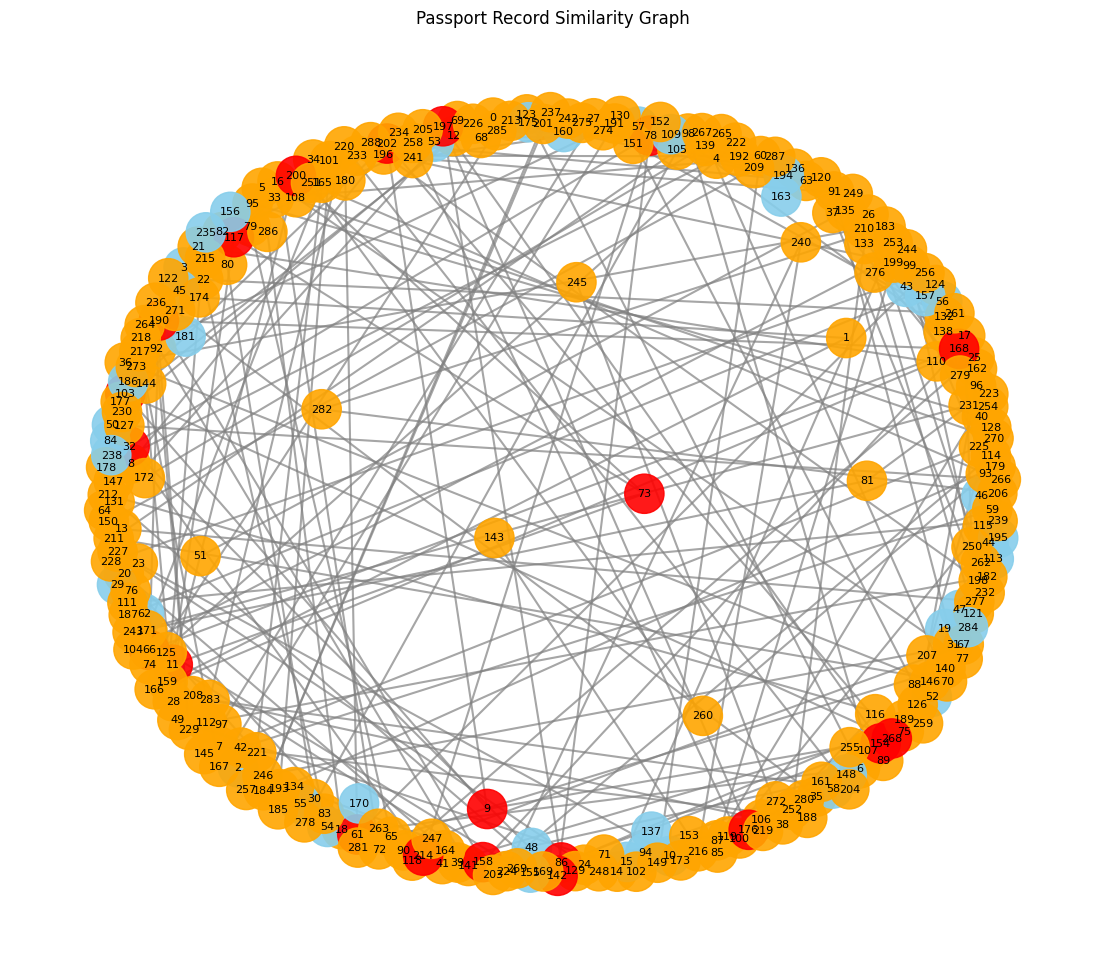

In [7]:
import matplotlib.pyplot as plt

plt.figure(figsize=(14,12))   # bigger canvas

# Increase spacing between nodes
pos = nx.spring_layout(G, k=2.5, iterations=100, seed=42)

nx.draw_networkx_nodes(
    G, pos,
    node_color=node_colors,
    node_size=800,
    alpha=0.9
)

nx.draw_networkx_edges(
    G, pos,
    edge_color="gray",
    width=1.5,
    alpha=0.7
)

nx.draw_networkx_labels(
    G, pos,
    font_size=8
)

plt.title("Passport Record Similarity Graph")
plt.axis("off")   # removes axis for cleaner graph
plt.show()

## **Training the GNN model**

**Install libraries**

In [8]:
!pip install sentence-transformers torch-geometric

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 63.7/63.7 kB 2.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 17.7 MB/s eta 0:00:00


**Import libraries**

In [38]:
# Convert NetworkX graph to PyTorch Geometric format
from torch_geometric.utils import from_networkx
data = from_networkx(G)

In [10]:
# Load Sentence Transformer model
from sentence_transformers import SentenceTransformer
model_embed = SentenceTransformer("all-MiniLM-L6-v2")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

...

tokenizer_config.json:   0%|          | 0.00/350 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

**Data Preprocessing**

In [11]:
# Prepare text fields for embeddings
names = [
    f"{rec.get('given_name','')} {rec.get('surname','')}".strip()
    for rec in all_records
]

places_birth = [
    rec.get("place_of_birth","") if rec.get("place_of_birth") else ""
    for rec in all_records
]

places_issue = [
    rec.get("place_of_issue","") if rec.get("place_of_issue") else ""
    for rec in all_records
]


# Generate embeddings
name_vectors = model_embed.encode(names)
birth_place_vectors = model_embed.encode(places_birth)
issue_place_vectors = model_embed.encode(places_issue)

In [12]:
# Extract numeric features
numeric_features = []

for rec in all_records:

    # Sex encoding
    sex_map = {"M":1, "F":2}
    sex = sex_map.get(rec.get("sex"), 0)

    # Nationality encoding
    nationality = rec.get("nationality","")
    nationality_num = sum([ord(c) for c in nationality]) % 1000 if nationality else 0

    # DOB extraction
    day = 0
    month = 0
    year = 0

    dob = rec.get("date_of_birth","")

    if dob:
        try:
            parts = dob.split()

            if len(parts) == 3:
                day = int(parts[0])
                year = int(parts[2])

                month_map = {
                    "JAN":1,"FEB":2,"MAR":3,"APR":4,"MAY":5,"JUN":6,
                    "JUL":7,"AUG":8,"SEP":9,"OCT":10,"NOV":11,"DEC":12
                }

                month = month_map.get(parts[1].upper(),0)

        except:
            pass

    numeric_features.append([sex, nationality_num, day, month, year])


import numpy as np
numeric_features = np.array(numeric_features)

In [13]:
# Combine all features
features = np.concatenate([
    name_vectors,
    birth_place_vectors,
    issue_place_vectors,
    numeric_features
], axis=1)

In [14]:
# Normalize features
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
features = scaler.fit_transform(features)

In [15]:

# Convert to PyTorch tensor
import torch
X = torch.tensor(features, dtype=torch.float)

In [16]:

# Assign features to graph
data = from_networkx(G)
data.x = X


In [17]:
# Check feature shape
print("Passport feature tensor shape:", data.x.shape)

Passport feature tensor shape: torch.Size([289, 1157])


In [19]:
# Show feature vector for the first record
record_index = 0
print(f"Feature vector for record {record_index+1} ({all_records[record_index]['_filename']}):\n")
print(X[record_index])

Feature vector for record 1 (00841c9e990444218da8aa17a46e3f8c_img5_jpeg_jpg.rf.af7fbafeb150e72ce61f0ea507d74eee.jpg):

tensor([0.2489, 1.2042, 0.2877,  ..., 0.0316, 1.5360, 0.7353])


**Training the GNN model**

In [20]:
import torch
import torch.nn.functional as F
from torch_geometric.nn import GCNConv

class GNN(torch.nn.Module):
    def __init__(self, in_channels):
        super().__init__()
        self.conv1 = GCNConv(in_channels, 128)
        self.conv2 = GCNConv(128, 64)

    def forward(self, x, edge_index):
        x = self.conv1(x, edge_index)
        x = F.relu(x)
        x = self.conv2(x, edge_index)
        return x

In [23]:
# 2️ Initialize model
in_dim = X.shape[1]   # feature vector size
model = GNN(in_channels=in_dim)

optimizer = torch.optim.Adam(model.parameters(), lr=0.01)

In [24]:

# 3️ Train the model
for epoch in range(200):
    model.train()
    optimizer.zero_grad()

    out = model(data.x, data.edge_index)

    # Unsupervised anomaly learning
    loss = torch.mean(out**2)

    loss.backward()
    optimizer.step()

    if epoch % 20 == 0:
        print("Epoch:", epoch, "Loss:", loss.item())

Epoch: 0 Loss: 1.2520475387573242
Epoch: 20 Loss: 0.06113705039024353
Epoch: 40 Loss: 0.007498711347579956
Epoch: 60 Loss: 0.0011629729997366667
Epoch: 80 Loss: 0.0007127642747946084
Epoch: 100 Loss: 0.0005463038687594235
Epoch: 120 Loss: 0.0037736522499471903
Epoch: 140 Loss: 0.0018989179516211152
Epoch: 160 Loss: 0.00015759615052957088
Epoch: 180 Loss: 3.92896581615787e-05


In [25]:
# 4️ Compute anomaly scores
model.eval()

with torch.no_grad():
    embeddings = model(data.x, data.edge_index)

    # L2 norm → anomaly score
    scores = torch.norm(embeddings, dim=1)

print("\n--- Passport Record Anomaly Scores ---\n")

for i, s in enumerate(scores):
    print(f"Record {i} ({all_records[i]['_filename']}): Anomaly Score = {float(s):.4f}")


--- Passport Record Anomaly Scores ---

Record 0 (00841c9e990444218da8aa17a46e3f8c_img5_jpeg_jpg.rf.af7fbafeb150e72ce61f0ea507d74eee.jpg): Anomaly Score = 0.0121
Record 1 (026c2b66a7284b87ae1ba1bb9f97517c_img13_jpeg_jpg.rf.7b18b1f44c6324c3550de4aa8c8b325e.jpg): Anomaly Score = 0.0193
Record 2 (0785c8f42bbd4e7cbda60f449a96cbc6_1055_0_png.rf.867f82ac80c181f418e52ba0dd7a68b4.jpg): Anomaly Score = 0.0171
Record 3 (0954b0558be74eff9023fade313ce52a_1013_0_png.rf.a65f56c33d8f09ce1ae4b91492f2f546.jpg): Anomaly Score = 0.0171
Record 4 (1000_0_png.rf.96a7ae75b92c368d0acf5808c7b09ae6.jpg): Anomaly Score = 0.0168
Record 5 (1001_0_png.rf.73f4ab32b083d10f174fab9300717cdb.jpg): Anomaly Score = 0.0463
Record 6 (1002_0_png.rf.09ad8cb58d6773f24f77b8a56f3f1103.jpg): Anomaly Score = 0.0166
Record 7 (1003_0_png.rf.a7063d809fc26dace4b983534db0c27f.jpg): Anomaly Score = 0.0261
Record 8 (1004_0_png.rf.fa495ff260033085c41ba14f40ac7797.jpg): Anomaly Score = 0.0169
Record 9 (1005_0_png.rf.1a61e1e9935a583994bd74

**Saving the model**

In [26]:
# 6️ Save the trained model
torch.save(model.state_dict(), "passport_gnn_model.pth")

In [27]:
# 7️ Load the model later (if needed)
model.load_state_dict(torch.load("passport_gnn_model.pth"))
model.eval()

GNN(
  (conv1): GCNConv(1157, 128)
  (conv2): GCNConv(128, 64)
)

**Testing on Single sample**

In [29]:
# Select one passport record from the dataset
record_index = 0
rec = all_records[record_index]
print("Testing record:", rec["_filename"])


Testing record: 00841c9e990444218da8aa17a46e3f8c_img5_jpeg_jpg.rf.af7fbafeb150e72ce61f0ea507d74eee.jpg


In [30]:
# Function to extract numeric passport features (same logic used during training)
def extract_numeric_features_passport(rec):

    # Encode sex: M=1, F=2, unknown=0
    sex_map = {"M":1, "F":2}
    sex = sex_map.get(rec.get("sex"), 0)

    # Convert nationality text to a numeric representation
    nationality = rec.get("nationality", "")
    nationality_num = sum([ord(c) for c in nationality]) % 1000 if nationality else 0

    # Initialize DOB values
    day, month, year = 0, 0, 0
    dob = rec.get("date_of_birth", "")

    # Extract day, month, year from DOB
    if dob:
        try:
            parts = dob.split()
            if len(parts) == 3:
                day = int(parts[0])
                year = int(parts[2])

                # Convert month text to numeric value
                month_map = {
                    "JAN":1,"FEB":2,"MAR":3,"APR":4,"MAY":5,"JUN":6,
                    "JUL":7,"AUG":8,"SEP":9,"OCT":10,"NOV":11,"DEC":12
                }

                month = month_map.get(parts[1].upper(),0)
        except:
            pass

    return np.array([sex, nationality_num, day, month, year])


In [31]:
# Convert passport text fields to embeddings
name = [rec.get("name", "")]
birth_place = [rec.get("place_of_birth", "")]
issue_place = [rec.get("place_of_issue", "")]

name_vec = model_embed.encode(name)
birth_vec = model_embed.encode(birth_place)
issue_vec = model_embed.encode(issue_place)

In [32]:
# Extract numeric passport features
numeric = extract_numeric_features_passport(rec).reshape(1, -1)

# Combine embeddings and numeric features into a single feature vector
features_combined = np.concatenate([
    name_vec,
    birth_vec,
    issue_vec,
    numeric
], axis=1)

# Normalize the features using the same scaler used during training
features_scaled = scaler.transform(features_combined)

# Convert the feature vector into a PyTorch tensor
sample_x = torch.tensor(features_scaled, dtype=torch.float)

# Create an empty graph edge index since this is a single isolated node
empty_edge_index = torch.empty((2,0), dtype=torch.long)

# Run the GNN model to compute embeddings and anomaly score
model.eval()
with torch.no_grad():
    embeddings = model(sample_x, empty_edge_index)
    score = torch.norm(embeddings, dim=1).item()

print("Anomaly Score:", score)

Anomaly Score: 4.344247341156006


In [34]:
# Decide whether the passport record is normal or suspicious
threshold = 2
if score > threshold:
    print("☑ Suspicious Passport Record")
else:
    print("✅ Normal Passport Record")

# Print the passport record details
print(rec)

☑ Suspicious Passport Record
{'_filename': '00841c9e990444218da8aa17a46e3f8c_img5_jpeg_jpg.rf.af7fbafeb150e72ce61f0ea507d74eee.jpg', 'surname': 'SHAIKH', 'given_name': 'MOHAMED YUSUF ABDUL WAHAB', 'nationality': 'INDIAN', 'sex': 'M', 'date_of_birth': '10 OCT 1960', 'place_of_birth': 'AHMEDABAD', 'place_of_issue': 'JEDDAH'}


In [35]:
print(rec)

{'_filename': '00841c9e990444218da8aa17a46e3f8c_img5_jpeg_jpg.rf.af7fbafeb150e72ce61f0ea507d74eee.jpg', 'surname': 'SHAIKH', 'given_name': 'MOHAMED YUSUF ABDUL WAHAB', 'nationality': 'INDIAN', 'sex': 'M', 'date_of_birth': '10 OCT 1960', 'place_of_birth': 'AHMEDABAD', 'place_of_issue': 'JEDDAH'}


In [36]:
# Print details of the input Passport record
print("Input Passport Record:")
print(rec)
print()

# Normalize vectors for cosine similarity
sample_norm = F.normalize(sample_x, dim=1)
nodes_norm = F.normalize(data.x, dim=1)

# Compute similarity scores between input passport and dataset passports
similarities = torch.mm(sample_norm, nodes_norm.T)

# Get top 5 most similar passport records
top_k = 5
values, indices = torch.topk(similarities, top_k)

print("Most similar Passport records in dataset:")

for i in range(top_k):
    node_id = indices[0][i].item()
    sim_score = values[0][i].item()
    rec_sim = all_records[node_id]

    print(f"Node {node_id}  Similarity: {sim_score:.4f}")
    print(rec_sim)  # print full passport record
    print()

Input Passport Record:
{'_filename': '00841c9e990444218da8aa17a46e3f8c_img5_jpeg_jpg.rf.af7fbafeb150e72ce61f0ea507d74eee.jpg', 'surname': 'SHAIKH', 'given_name': 'MOHAMED YUSUF ABDUL WAHAB', 'nationality': 'INDIAN', 'sex': 'M', 'date_of_birth': '10 OCT 1960', 'place_of_birth': 'AHMEDABAD', 'place_of_issue': 'JEDDAH'}

Most similar Passport records in dataset:
Node 0  Similarity: 0.5670
{'_filename': '00841c9e990444218da8aa17a46e3f8c_img5_jpeg_jpg.rf.af7fbafeb150e72ce61f0ea507d74eee.jpg', 'surname': 'SHAIKH', 'given_name': 'MOHAMED YUSUF ABDUL WAHAB', 'nationality': 'INDIAN', 'sex': 'M', 'date_of_birth': '10 OCT 1960', 'place_of_birth': 'AHMEDABAD', 'place_of_issue': 'JEDDAH'}

Node 63  Similarity: 0.5670
{'_filename': '25d4feeea5694f24ab1a94e44dddc794_img5_jpeg_jpg.rf.033dcfd24fef4cd284a3b06b40ede740.jpg', 'surname': 'SHAIKH', 'given_name': 'MOHAMED YUSUF ABDUL WAHAB', 'nationality': 'INDIAN', 'sex': 'M', 'date_of_birth': '10 OCT 1960', 'place_of_birth': 'AHMEDABAD', 'place_of_issue': 